In [19]:
# Module 1: Import Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib


In [20]:
# Module 2: Load Dataset
df = pd.read_csv("task4/data/emails.csv")   # adjust path if needed
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (5172, 3002)


,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0


In [21]:
# Module 3: Explore Dataset
print(df.info())
print("Columns:", df.columns)
print(df['Prediction'].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5172 entries, 0 to 5171
Columns: 3002 entries, Email No. to Prediction
dtypes: int64(3001), object(1)
memory usage: 118.5+ MB
None
Columns: Index(['Email No.', 'the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou',
       ...
       'connevey', 'jay', 'valued', 'lay', 'infrastructure', 'military',
       'allowing', 'ff', 'dry', 'Prediction'],
      dtype='object', length=3002)
Prediction
0    3672
1    1500
Name: count, dtype: int64


In [9]:
# Module 4: Preprocess Data
df = df.dropna()

# Encode labels (spam/ham → 0/1)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df[label_col] = le.fit_transform(df[label_col])


In [22]:
# Module 5: Feature Extraction
# Drop non-numeric identifier column and target column
X = df.drop(columns=['Prediction', 'Email No.'])

# Keep only numeric columns (word features)
X = X.select_dtypes(include=['int64', 'float64'])

# Target labels
y = df['Prediction']


In [23]:
# Module 6: Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [24]:
# Module 7: Model Training
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


Accuracy: 0.9719806763285024
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       739
           1       0.94      0.96      0.95       296

    accuracy                           0.97      1035
   macro avg       0.96      0.97      0.97      1035
weighted avg       0.97      0.97      0.97      1035



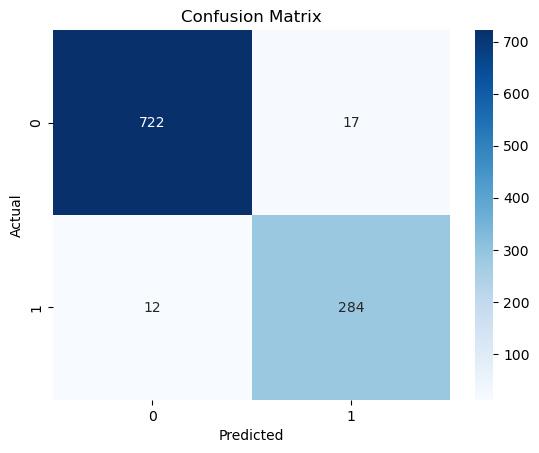

In [26]:
# Module 8: Evaluation
import os

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Ensure reports folder exists
os.makedirs("task4/reports", exist_ok=True)

# Save confusion matrix plot
plt.savefig("task4/reports/confusion_matrix.png")
plt.show()


In [27]:
# Module 9: Save Model
import os
import joblib

# Ensure models folder exists
os.makedirs("task4/models", exist_ok=True)

# Save the trained model
joblib.dump(model, "task4/models/email_model.pkl")

print("✅ Model saved successfully!")


✅ Model saved successfully!


In [28]:
# Module 10: Prediction on New Emails

import joblib
import pandas as pd

# Load the saved model
loaded_model = joblib.load("task4/models/email_model.pkl")

# Example: create a new email feature row
# IMPORTANT: It must have the same structure (same word columns) as your training data
# Here we build a DataFrame with one row, matching the feature columns
new_email = pd.DataFrame([[0]*X.shape[1]], columns=X.columns)

# Example: set some word counts manually
new_email.loc[0, 'free'] = 1
new_email.loc[0, 'money'] = 2
new_email.loc[0, 'offer'] = 1

# Predict using the loaded model
prediction = loaded_model.predict(new_email)[0]

print("Prediction:", prediction)


Prediction: 1


In [31]:
# Module 11: Batch Predictions on Multiple Emails

import joblib
import pandas as pd

# Load the saved model
loaded_model = joblib.load("task4/models/email_model.pkl")

# Use the same feature columns as training
feature_cols = list(X.columns)

# Create a batch of 3 new emails with all zeros
batch_emails = pd.DataFrame(0, index=range(3), columns=feature_cols)

# Set word counts for each email (only if those words exist in your dataset)
if 'free' in batch_emails.columns:
    batch_emails.loc[0, 'free'] = 1
if 'money' in batch_emails.columns:
    batch_emails.loc[0, 'money'] = 2
if 'offer' in batch_emails.columns:
    batch_emails.loc[2, 'offer'] = 1
if 'win' in batch_emails.columns:
    batch_emails.loc[2, 'win'] = 1

# Predict for all emails
batch_predictions = loaded_model.predict(batch_emails)

print("Batch Predictions:", batch_predictions)  # array of 0 (ham) or 1 (spam)


Batch Predictions: [1 1 1]


In [32]:
# Module 12: Alternative Models

from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Train Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)
print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))


Naive Bayes Accuracy: 0.9545893719806763
Random Forest Accuracy: 0.9777777777777777
